In [1]:
#Import des librairies de bases necessaires
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

 Pour cette première partie, nous traitons le problème comme une étude de cas historique où les variables sont des constantes observées. L'objectif est de voir ce que "le passé nous dit" avant d'injecter de la complexité probabiliste avec le modèle de Strickler

In [2]:
data = pd.read_excel("Données-Projet-Pratique-Fiabilité-ISUP-SCDI_E-Remy_2025-2026.xlsx")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 3 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Année                                  149 non-null    int64  
 1   Débit mesuré maximal annuel (en m3/s)  149 non-null    float64
 2   Hauteur associée mesurée (en m)        123 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 3.6 KB


In [4]:
data

,Année,Débit mesuré maximal annuel (en m3/s),Hauteur associée mesurée (en m)
0,1849,3853.892756,NaN
1,1850,1256.402143,4.0
2,1851,1648.542191,4.5
3,1852,1604.857094,4.3
4,1853,341.157419,1.7
...,...,...,...
144,1993,740.178695,3.1
145,1994,3044.380648,7.2
146,1995,1127.889906,3.5
147,1996,522.151370,2.5


In [5]:
data.describe()

,Année,Débit mesuré maximal annuel (en m3/s),Hauteur associée mesurée (en m)
count,149.000000,149.000000,123.000000
mean,1923.000000,1335.419913,3.896748
std,43.156691,713.926746,1.272337
min,1849.000000,122.435600,1.000000
25%,1886.000000,799.918835,3.100000
50%,1923.000000,1256.402143,3.900000
75%,1960.000000,1694.929723,4.750000
max,1997.000000,3853.892756,7.200000


In [6]:
#Les constantes clés pour la première approche
L = 5000 #Longueur du tronçon
B = 300 # Largeur du cours d'eau 
Z_b = 55.5 # cote berge

In [7]:
#Ici on prend pour valeurs des cotes de la fond du cours d'eau en amont et en avale de la rivière leur espérance
#  qui constitue la meilleur estimation de  la réalité physique
Z_m = 55 
Z_v = 50

Ensuite on va calculer les valeurs de $K{s}$ pour toutes les lignes avec des informations complètes en utilisant la formule donnée:
$$
K_s = \frac{Q}{H^{5/3} \cdot B \cdot \sqrt{\frac{Z_m - Z_v}{L}}}
$$


In [8]:
#Ajout d'une colonne pour stocker les valeurs des Ks (calcualbles e.g correspondant aux hauteurs existantes)
Strickler_coef = [np.nan for i in range (149)]
data["Strickler_coef"] = Strickler_coef

In [9]:
data 

,Année,Débit mesuré maximal annuel (en m3/s),Hauteur associée mesurée (en m),Strickler_coef
0,1849,3853.892756,NaN,NaN
1,1850,1256.402143,4.0,NaN
2,1851,1648.542191,4.5,NaN
3,1852,1604.857094,4.3,NaN
4,1853,341.157419,1.7,NaN
...,...,...,...,...
144,1993,740.178695,3.1,NaN
145,1994,3044.380648,7.2,NaN
146,1995,1127.889906,3.5,NaN
147,1996,522.151370,2.5,NaN


In [9]:
for i in range(149):
    value = data["Hauteur associée mesurée (en m)"].iloc[i]
    
    if pd.notna(value):
        data.loc[i, "Strickler_coef"] = (
            data.loc[i, "Débit mesuré maximal annuel (en m3/s)"] /
            (
                (data.loc[i, "Hauteur associée mesurée (en m)"] ** (5/3)) *
                np.sqrt((Z_m - Z_v) / L) *
                B
            )
        )

In [10]:
data

,Année,Débit mesuré maximal annuel (en m3/s),Hauteur associée mesurée (en m),Strickler_coef
0,1849,3853.892756,NaN,NaN
1,1850,1256.402143,4.0,13.139356
2,1851,1648.542191,4.5,14.167437
3,1852,1604.857094,4.3,14.877650
4,1853,341.157419,1.7,14.850875
...,...,...,...,...
144,1993,740.178695,3.1,11.838023
145,1994,3044.380648,7.2,11.953366
146,1995,1127.889906,3.5,14.735517
147,1996,522.151370,2.5,11.952034


In [6]:
data

,Année,Débit mesuré maximal annuel (en m3/s),Hauteur associée mesurée (en m)
0,1849,3853.892756,NaN
1,1850,1256.402143,4.0
2,1851,1648.542191,4.5
3,1852,1604.857094,4.3
4,1853,341.157419,1.7
...,...,...,...
144,1993,740.178695,3.1
145,1994,3044.380648,7.2
146,1995,1127.889906,3.5
147,1996,522.151370,2.5


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 4 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Année                                  149 non-null    int64  
 1   Débit mesuré maximal annuel (en m3/s)  149 non-null    float64
 2   Hauteur associée mesurée (en m)        123 non-null    float64
 3   Strickler_coef                         123 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 4.8 KB


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 4 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Année                                  149 non-null    int64  
 1   Débit mesuré maximal annuel (en m3/s)  149 non-null    float64
 2   Hauteur associée mesurée (en m)        123 non-null    float64
 3   Strickler_coef                         123 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 4.8 KB


In [12]:
# moyenne du coefficient(correspondant au Ks_obs
Ks_mean = data["Strickler_coef"].mean()

print(Ks_mean)

13.556592854942814


## Première approche – Choix déterministe du coefficient de Strickler et reconstruction des données manquantes

### Objectif de la démarche

L’objectif de cette première approche est de proposer une hauteur de digue à partir de l’exploitation
des seules données historiques disponibles. Pour ce faire, il est nécessaire de disposer d’un jeu
de données cohérent de hauteurs de crue $H$.

Certaines valeurs de $H$ étant manquantes dans le jeu de données, un modèle hydraulique simplifié
est utilisé afin de reconstituer ces hauteurs à partir des débits observés $Q$. Cette étape nécessite
le choix d’un coefficient de Strickler $K_s$ constant et déterministe.

---

### Estimation du coefficient de Strickler à partir des données observées

À partir des couples de données observées $(Q, H)$ disponibles, le modèle hydraulique simplifié
a été inversé afin d’estimer une valeur équivalente du coefficient de Strickler $K_s$.

La valeur moyenne obtenue est :

$$
\overline{K_s}^{\text{obs}} \approx 13.56
$$

Cette valeur correspond à un **coefficient hydraulique effectif**, intégrant à la fois les propriétés
physiques du cours d’eau et les simplifications du modèle utilisé.

---

### Justification du choix de $K_s$ pour la première approche

Dans cette première approche, le coefficient de Strickler retenu est :

$$
K_s = \overline{K_s}^{\text{obs}} \approx 13.56
$$

Ce choix est justifié par les éléments suivants :

- la démarche s’inscrit dans une **logique rétrospective**, visant à exploiter et compléter un jeu de
  données historiques existant ;
- la valeur $\overline{K_s}^{\text{obs}}$ est **calibrée sur les observations disponibles**, garantissant
  une cohérence interne du jeu de données reconstitué ;
- le coefficient $K_s$ agit ici comme un **paramètre de calibration du modèle**, et non comme une
  grandeur physique indépendante destinée à la prédiction ;
- l’utilisation d’une valeur experte indépendante des données introduirait un biais exogène non
  justifié dans le cadre de cette première approche déterministe.

La valeur experte de $K_s$ sera introduite ultérieurement dans les approches probabiliste et
économique, lorsque l’objectif deviendra prédictif et décisionnel.

---

### Reconstruction des hauteurs de crue manquantes

Les hauteurs de crue manquantes $H$ sont estimées à partir des débits observés $Q$ en utilisant le
modèle hydraulique simplifié :

$$
H = \left(
\frac{Q}{K_s \sqrt{\frac{Z_m - Z_v}{L}} \, B}
\right)^{3/5}
$$

avec $K_s = 13.56$ et les paramètres géométriques supposés connus.

Cette reconstruction permet d’obtenir un jeu de données complet et cohérent de hauteurs de crue
sur l’ensemble de la période étudiée.

---

### Détermination de la cote de digue à partir des données complétées

À partir des hauteurs de crue reconstruites, la cote maximale de crue est estimée par :

$$
Z_c = Z_v + H
$$

La cote de la digue est alors choisie de manière à minimiser le risque d’inondation sur la base des
observations historiques, par exemple en retenant :
- la cote maximale observée,
- ou un quantile empirique élevé (crue centennale empirique),
- éventuellement augmentée d’une marge de sécurité.

Cette approche fournit une première estimation de la hauteur de digue, fondée exclusivement sur
l’analyse déterministe des données historiques.


In [13]:
for i in range(149):
    value = data.loc[i, "Hauteur associée mesurée (en m)"]
    
    if pd.isna(value):
        data.loc[i, "Hauteur associée mesurée (en m)"] = (
            data.loc[i, "Débit mesuré maximal annuel (en m3/s)"] /
            (
                data["Strickler_coef"].mean() *
                B *
                np.sqrt((Z_m - Z_v) / L)
            )
        ) ** (3/5)

In [14]:
data.describe()

,Année,Débit mesuré maximal annuel (en m3/s),Hauteur associée mesurée (en m),Strickler_coef
count,149.000000,149.000000,149.000000,123.000000
mean,1923.000000,1335.419913,3.948265,13.556593
std,43.156691,713.926746,1.300420,1.374514
min,1849.000000,122.435600,1.000000,11.362736
25%,1886.000000,799.918835,3.100000,12.328945
50%,1923.000000,1256.402143,3.961014,13.388969
75%,1960.000000,1694.929723,4.756370,14.730617
max,1997.000000,3853.892756,7.690892,16.183475


## Première approche – Analyse descriptive et choix de la hauteur de digue

### Statistiques descriptives après reconstruction des hauteurs manquantes

Après reconstruction des hauteurs de crue manquantes à l’aide du modèle hydraulique simplifié, le jeu
de données comprend 149 observations complètes. Les statistiques descriptives de la hauteur de crue
$H$ sont résumées ci-dessous :

- hauteur minimale observée : $H_{\min} = 1.00\ \text{m}$
- hauteur moyenne : $\mathbb{E}[H] \approx 3.95\ \text{m}$
- médiane : $H_{50\%} \approx 3.96\ \text{m}$
- troisième quartile : $H_{75\%} \approx 4.76\ \text{m}$
- hauteur maximale observée :  
  $$
  H_{\max} = 7.69\ \text{m}
  $$

La dispersion observée traduit la forte variabilité interannuelle des crues, avec quelques événements
extrêmes nettement plus élevés que la tendance centrale.

---

### Critère de sûreté retenu

Dans cette première approche, fondée exclusivement sur l’analyse des données historiques, un
critère de sûreté simple et conservateur est retenu :

> *La digue doit protéger l’installation contre l’ensemble des crues observées sur la période
> historique considérée.*

Ce critère conduit à dimensionner la digue à partir de la hauteur maximale de crue observée.

---

### Choix de la hauteur de la digue

La hauteur de la digue est donc choisie telle que la surverse soit nulle ou négative pour l’événement
le plus défavorable observé, soit :

$$
h_d = H_{\max}
$$

ce qui conduit à :

$$
h_d \approx 7.7\ \text{m}
$$

Cette valeur constitue une **hauteur de digue déterministe de référence**, garantissant l’absence
d’inondation pour toutes les crues observées sur la période de 149 ans.

---

### Discussion et limites de l’approche

Ce dimensionnement est volontairement conservateur et présente plusieurs limites :

- il repose uniquement sur des observations passées et ne permet pas d’extrapoler à des crues plus
  rares que celles observées ;
- il ne tient pas compte explicitement des incertitudes physiques et statistiques ;
- il peut conduire à un surdimensionnement de la digue du point de vue économique.

Néanmoins, cette première approche fournit un **point de comparaison robuste** pour les approches
probabiliste et économique développées par la suite.


# 2.APPROCHE HYDROLIQUE

# Deuxième approche – Dimensionnement probabiliste de la digue

## 1. Objectif de la démarche

Contrairement à la première approche fondée sur l’exploitation des données historiques,
cette seconde approche repose sur une modélisation probabiliste des incertitudes.

L’objectif est de déterminer la hauteur de digue $h_d$ minimisant le risque de surverse,
c’est-à-dire la probabilité :

$$
P(S > 0)
$$

où $S$ désigne la hauteur de surverse définie par :

$$
S = Z_v + H - h_d - Z_b
$$

Une surverse se produit lorsque $S > 0$.

---

## 2. Modélisation probabiliste des variables

Les incertitudes hydrauliques et géométriques sont modélisées par les lois suivantes :

- Débit :
$$
Q \sim \text{Gumbel}(\mu = 1013,\ \beta = 558)
$$

- Coefficient de Strickler :
$$
K_s \sim \mathcal{N}(30,\ 7.5^2)
$$

- Cote du fond aval :
$$
Z_v \sim \text{Triangulaire}(49,\ 50,\ 51)
$$

- Cote du fond amont :
$$
Z_m \sim \text{Triangulaire}(54,\ 55,\ 56)
$$

Les constantes géométriques sont :

$$
L = 5000, \quad B = 300, \quad Z_b = 55.5
$$

---

## 3. Modèle hydraulique

Pour chaque réalisation, la hauteur d’eau est calculée par :

$$
H =
\left(
\frac{Q}
{K_s B \sqrt{\frac{Z_m - Z_v}{L}}}
\right)^{3/5}
$$

La surverse est ensuite :

$$
S = Z_v + H - h_d - Z_b
$$

---

## 4. Méthode de simulation (Monte-Carlo)

La probabilité de surverse est estimée par simulation de Monte-Carlo :

1. Générer $N$ réalisations indépendantes des variables aléatoires.
2. Calculer $H$ puis $S$ pour chaque réalisation.
3. Compter le nombre de cas où $S > 0$.
4. Estimer la probabilité :

$$
\widehat{P}(S>0)
=
\frac{1}{N}
\sum_{i=1}^{N} \mathbf{1}_{\{S_i > 0\}}
$$

où $\mathbf{1}$ est la fonction indicatrice.

---

## 5. Stratégie de dimensionnement

On teste différentes valeurs de $h_d$.

La hauteur optimale correspond à la plus petite valeur de $h_d$
telle que :

$$
P(S>0) \leq \alpha
$$

où $\alpha$ est un niveau de risque acceptable
(par exemple 1 % ou 0.1 %).

Cette approche permet d’intégrer explicitement l’incertitude
et de comparer le résultat obtenu avec la hauteur déterministe
issue de la première partie.

# Dimensionnement probabiliste de la digue par quantiles

## 1. Principe théorique

On définit :

$$
X = Z_v + H - Z_b
$$

La surverse se produit lorsque :

$$
S > 0 \quad \Longleftrightarrow \quad X > h_d
$$

Donc :

$$
P(S>0) = P(X > h_d)
$$

Pour garantir un niveau de risque fixé $\alpha$, on cherche :

$$
h_d^\star = F_X^{-1}(1-\alpha)
$$

Autrement dit : la hauteur optimale correspond au **quantile d’ordre $1-\alpha$** de la variable $X$.

---

## 2. Niveaux de risque étudiés

Nous considérons trois niveaux de sécurité :

- $1\%$
- $0.1\%$
- $0.01\%$

Ce qui correspond aux quantiles :

- $99\%$
- $99.9\%$
- $99.99\%$

---

## 3. Interprétation physique

- Si le quantile est **négatif** → aucune digue n'est nécessaire.
- Si le quantile est **positif** → il faut une digue au moins égale à cette valeur.
- Plus le risque admissible $\alpha$ diminue, plus la hauteur optimale $h_d$ augmente.
- Cette croissance dépend fortement du comportement de la **queue de distribution** de la variable $X$.

---

In [16]:
# Constantes
L = 5000
B = 300
Z_b = 55.5

# Nombre de simulations
N = 100000

In [50]:
np.random.# Triangulaires
Z_v = np.random.triangular(left=49, mode=50, right=51, size=N)
Z_m = np.random.triangular(left=54, mode=55, right=56, size=N)

In [62]:
Ks = np.random.normal(30, 7.5, N)
Ks = np.clip(Ks, 10, None) # Force ks à etre positive et à ne pas prendre des valeurs très faible(l'impose à etre dans une borne cohérente)

Q = np.random.gumbel(1013, 558, N)
Q = np.clip(Q, 1e-6, None)    # force Q > 0

In [63]:
H = (
    Q /
    (Ks * B * np.sqrt((Z_m - Z_v) / L))
) ** (3/5)

In [64]:
print("Min H :", np.min(H))
print("Mean H :", np.mean(H))
print("Max H :", np.max(H))
print("Quantiles :", np.percentile(H, [90,95,99,99.9]))

Min H : 6.111825873718783e-06
Mean H : 2.534285424502372
Max H : 11.74778068727162
Quantiles : [3.75851099 4.26179041 5.43186873 7.20772855]


In [65]:
X = Z_v + H - Z_b

print("Quantiles de X :", np.percentile(X, [90,95,99,99.9]))

Quantiles de X : [-1.60476434 -1.07785416  0.09396606  1.83777533]


In [66]:
h_min = np.percentile(X, 90) - 0.5
h_max = np.percentile(X, 99.9) + 0.5

h_values = np.linspace(h_min, h_max, 100)

In [67]:
def prob_surverse(h_d):
    S = Z_v + H - h_d - Z_b
    return np.mean(S > 0)

In [68]:
probs = [prob_surverse(h) for h in h_values]

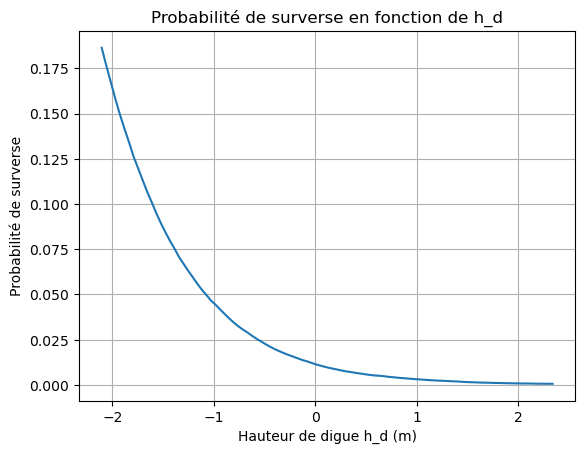

In [69]:
plt.figure()
plt.plot(h_values, probs)
plt.xlabel("Hauteur de digue h_d (m)")
plt.ylabel("Probabilité de surverse")
plt.title("Probabilité de surverse en fonction de h_d")
plt.grid()
plt.show()

In [70]:
alpha = 0.001  # 0.001 %

for h, p in zip(h_values, probs):
    if p <= alpha:
        h_opt = h
        break

print("Hauteur optimale pour un risque de 0.1% :", round(h_opt, 3), "m")
print("Probabilité associée :", prob_surverse(h_opt))

Hauteur optimale pour un risque de 0.1% : 1.844 m
Probabilité associée : 0.001


Risque 1.000%  →  h_d = 0.094 m
Risque 0.100%  →  h_d = 1.838 m
Risque 0.010%  →  h_d = 3.467 m


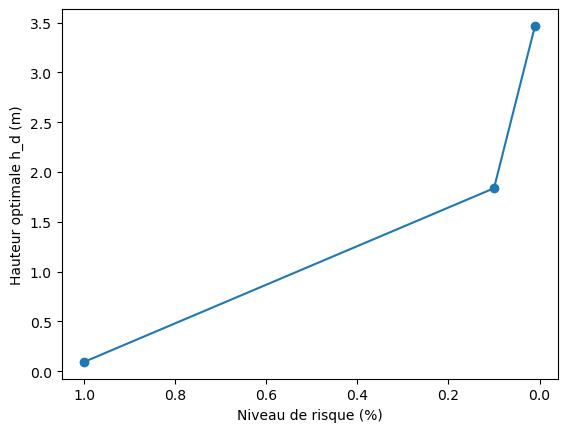

In [71]:
# Niveaux de risque
alphas = np.array([0.01, 0.001, 0.0001])  # 1%, 0.1%, 0.01%

# Calcul des hauteurs optimales (quantiles)
h_quantiles = np.quantile(X, 1 - alphas)

# Affichage des résultats
for a, h in zip(alphas, h_quantiles):
    print(f"Risque {a*100:.3f}%  →  h_d = {h:.3f} m")

# Tracé
plt.figure()
plt.plot(alphas*100, h_quantiles, marker='o')
plt.xlabel("Niveau de risque (%)")
plt.ylabel("Hauteur optimale h_d (m)")
plt.gca().invert_xaxis()
plt.show()

## Synthèse et interprétation de l’approche probabiliste

La seconde approche introduit un changement fondamental par rapport à l’analyse historique : 
on ne se limite plus aux événements observés mais on modélise explicitement les incertitudes 
à l’aide de variables aléatoires et d’une simulation de Monte-Carlo.

### 1. Interprétation du niveau de référence

Dans cette approche, la variable étudiée est :

$$
X = Z_v + H - Z_b
$$

La hauteur de digue $h_d$ représente donc **une protection additionnelle au-dessus de la berge existante $Z_b$**.

Ainsi :

- $h_d = 0$ correspond à l’état naturel du site (aucune digue supplémentaire).
- la probabilité de surverse $P(S>0)$ représente alors le risque que le niveau d’eau dépasse la berge.
- des valeurs négatives de $h_d$ ne correspondent pas à une digue réelle mais à un **scénario de vulnérabilité**, simulant un affaissement de la berge ou une élévation du lit de la rivière.

Cette interprétation permet de comprendre le comportement global du système et d’évaluer sa sensibilité aux variations du relief.

---

### 2. Mise en perspective avec l’analyse historique

L’approche historique avait montré que la plus grande hauteur d’eau observée était :

$$
H_{max} = 7.69 \, m
$$

Ce niveau correspond à un dépassement de la berge égal à :

$$
(Z_v + H_{max}) - Z_b \approx (50 + 7.69) - 55.5 \approx 2.19 \, m
$$

La simulation probabiliste montre que pour :

$$
h_d \approx 2.2 \, m
$$

la probabilité de surverse devient pratiquement nulle.

Le modèle probabiliste **confirme donc la rareté extrême de l’événement historique** : la crue maximale observée correspond vraisemblablement à un événement d’occurrence annuelle très faible (bien inférieure à $0.1\%$).

---

### 3. Une relation non linéaire entre sécurité et hauteur de digue

L’analyse de la courbe $P(S>0)$ en fonction de $h_d$ met en évidence un phénomène classique en ingénierie du risque : **la sécurité présente des rendements décroissants**.

On observe que :

- les premières augmentations de hauteur permettent une réduction rapide du risque ;
- ensuite, les gains de sécurité deviennent de plus en plus faibles pour une augmentation importante de la hauteur de digue.

Autrement dit, la réduction du risque est très efficace au début, puis devient progressivement plus coûteuse.  
La partie extrême de la courbe correspond aux événements rares décrits par la loi de Gumbel et aux incertitudes sur les paramètres géométriques du site.

---

### 4. Apport de l’approche probabiliste pour la décision

Contrairement à l’approche historique qui fournit une valeur unique basée sur le maximum observé, l’approche probabiliste permet de **relier directement la hauteur de digue au niveau de risque accepté**.

Elle offre ainsi plusieurs niveaux de décision possibles :

- **Option économique** : une digue faible au-dessus de la berge permet déjà de réduire significativement le risque.
- **Option standard de sécurité** : une hauteur intermédiaire correspond à un niveau de risque très faible (ordre de $10^{-3}$).
- **Option conservatrice** : une digue proche du dépassement historique garantit une protection contre les événements extrêmes observés.

---
### 5. Interprétation des niveaux de risque étudiés

Afin de relier directement la hauteur de digue au niveau de sécurité souhaité, plusieurs niveaux de risque ont été étudiés.  
Pour chaque probabilité cible $\alpha$, la hauteur optimale $h_d$ est obtenue en déterminant le quantile d’ordre $1-\alpha$ de la variable :

$$
X = Z_v + H - Z_b
$$

Les résultats obtenus sont les suivants :

- Risque de $1\%$  →  $h_d \approx 0.094$ m  
- Risque de $0.1\%$ →  $h_d \approx 1.838$ m  
- Risque de $0.01\%$ →  $h_d \approx 3.467$ m  

Ces valeurs montrent clairement l’effet du niveau de sécurité choisi sur le dimensionnement de l’ouvrage.

Pour un risque annuel de $1\%$, une protection très faible au-dessus de la berge suffit à limiter la probabilité de surverse.  
Cela signifie que la berge naturelle assure déjà une grande partie de la protection hydraulique.

En revanche, lorsque l’on impose un niveau de sécurité plus strict ($0.1\%$), la hauteur nécessaire augmente fortement pour atteindre $1.838$ m.  
Cette valeur correspond d’ailleurs très bien au dépassement associé à la crue historique maximale observée dans les données.

Enfin, pour un niveau de sécurité extrêmement conservateur ($0.01\%$), la hauteur de digue nécessaire dépasse $3$ m.  
Cette augmentation importante illustre le coût croissant associé à la protection contre les événements très rares.

Ces résultats mettent en évidence un principe classique en ingénierie du risque :  
la réduction du risque devient de plus en plus coûteuse à mesure que l’on cherche à se protéger contre des événements extrêmes.

Ainsi, l’approche probabiliste ne fournit pas une unique solution mais un **ensemble cohérent de choix possibles**, permettant d’adapter le dimensionnement de la digue au niveau de sécurité jugé acceptable par le décideur.